In [1]:
# Install if not already installed
import subprocess
subprocess.run(['pip', 'install', 'shap'], capture_output=True)

import shap
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)
print("✅ SHAP ready!")

c:\Users\Athisk K\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.52.0
✅ SHAP ready!


In [2]:
crop_model = pickle.load(open('../models/crop_model.pkl', 'rb'))
le_crop = pickle.load(open('../models/crop_encoder.pkl', 'rb'))

df = pd.read_csv('../datasets/cleaned_crop.csv')

X = df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['crop_encoded']

print("✅ Model and data loaded!")
print("Features:", X.columns.tolist())

✅ Model and data loaded!
Features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


In [3]:
explainer = shap.TreeExplainer(crop_model)
print("✅ SHAP Explainer created!")

✅ SHAP Explainer created!


In [4]:
# Sample farmer input
sample = pd.DataFrame([[90, 42, 43, 20.87, 82.00, 6.50, 202.93]],
                      columns=['N', 'P', 'K', 'temperature',
                               'humidity', 'ph', 'rainfall'])

# Get SHAP values for this sample
shap_values = explainer.shap_values(sample)

print("✅ SHAP values computed!")
print("Shape of SHAP values:", np.array(shap_values).shape)

✅ SHAP values computed!
Shape of SHAP values: (1, 7, 22)


In [5]:
proba = crop_model.predict_proba(sample)[0]
top_crop_idx = np.argmax(proba)
top_crop_name = le_crop.classes_[top_crop_idx]
top_crop_conf = proba[top_crop_idx] * 100

print(f"Top predicted crop: {top_crop_name.title()}")
print(f"Confidence: {top_crop_conf:.2f}%")
print(f"Crop index: {top_crop_idx}")

Top predicted crop: Rice
Confidence: 90.00%
Crop index: 20


SHAP values for top crop: [ 0.16558463  0.09393402  0.12393615  0.10216396  0.15679118 -0.00951958
  0.22135396]
Base value: 0.04575568181818181


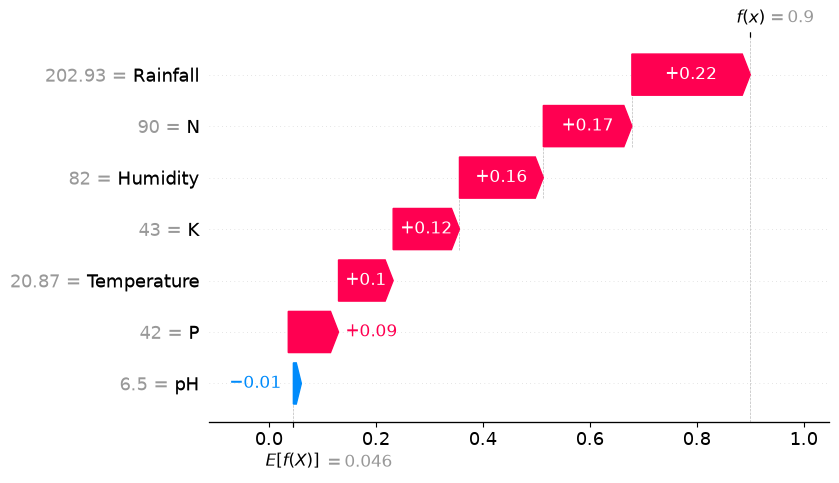

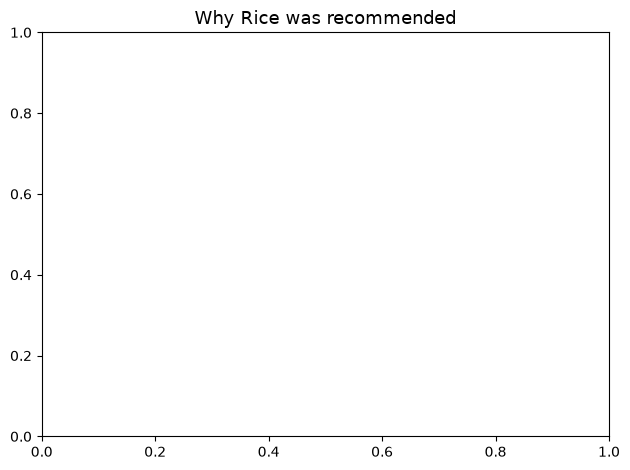

✅ Waterfall plot saved!


In [8]:
feature_names = ['N', 'P', 'K', 'Temperature', 'Humidity', 'pH', 'Rainfall']

# Correct indexing for shape (1, 7, 22)
# We need (features,) for the top crop
shap_vals_for_crop = shap_array[0, :, top_crop_idx]  # shape: (7,)
base_val = explainer.expected_value[top_crop_idx]

print("SHAP values for top crop:", shap_vals_for_crop)
print("Base value:", base_val)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_vals_for_crop,
        base_values=base_val,
        data=sample.values[0],
        feature_names=feature_names
    )
)
plt.title(f"Why {top_crop_name.title()} was recommended", fontsize=13)
plt.tight_layout()
plt.savefig('../models/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Waterfall plot saved!")

C:\Users\Athisk K\AppData\Local\Temp\ipykernel_8604\1211118199.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


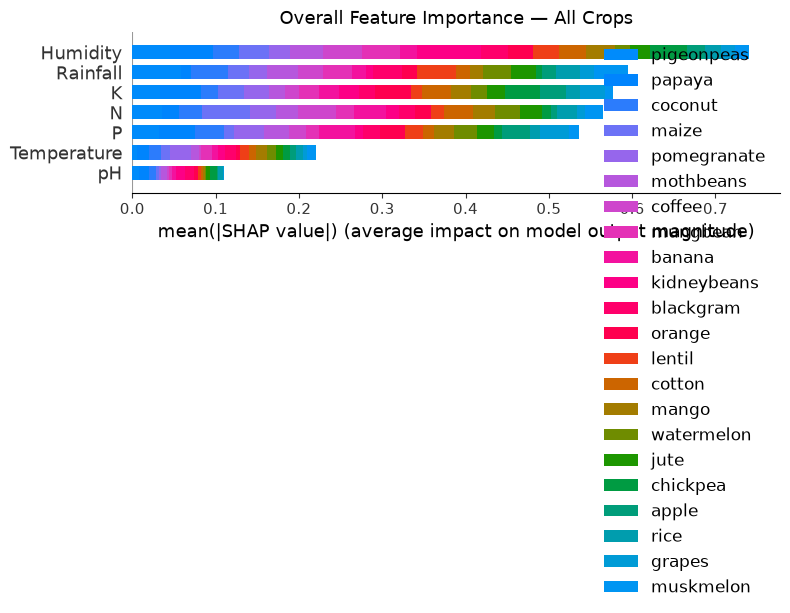

✅ Summary plot saved!


In [9]:
# Use a sample of data for summary plot
X_sample = X.sample(200, random_state=42)
shap_values_all = explainer.shap_values(X_sample)

shap.summary_plot(
    shap_values_all,
    X_sample,
    feature_names=feature_names,
    class_names=le_crop.classes_,
    plot_type='bar',
    show=False
)
plt.title("Overall Feature Importance — All Crops", fontsize=13)
plt.tight_layout()
plt.savefig('../models/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Summary plot saved!")

In [10]:
shap_vals = shap_array[0, :, top_crop_idx]
feature_names_list = ['N', 'P', 'K', 'Temperature', 'Humidity', 'pH', 'Rainfall']

importance_pairs = list(zip(feature_names_list, shap_vals))
importance_pairs.sort(key=lambda x: abs(x[1]), reverse=True)

print(f"🌾 Why {top_crop_name.title()} was recommended:")
print("-" * 45)
for feat, val in importance_pairs:
    direction = "✅ supported" if val > 0 else "⚠️ reduced confidence"
    print(f"  {feat:<15} → {direction} (impact: {val:+.4f})")

🌾 Why Rice was recommended:
---------------------------------------------
  Rainfall        → ✅ supported (impact: +0.2214)
  N               → ✅ supported (impact: +0.1656)
  Humidity        → ✅ supported (impact: +0.1568)
  K               → ✅ supported (impact: +0.1239)
  Temperature     → ✅ supported (impact: +0.1022)
  P               → ✅ supported (impact: +0.0939)
  pH              → ⚠️ reduced confidence (impact: -0.0095)


In [11]:
pickle.dump(explainer, open('../models/shap_explainer.pkl', 'wb'))
print("✅ SHAP explainer saved!")

✅ SHAP explainer saved!


In [12]:
print("=" * 40)
print("   PHASE 4 — SHAP COMPLETE")
print("=" * 40)

loaded_explainer = pickle.load(open('../models/shap_explainer.pkl', 'rb'))
test_shap = loaded_explainer.shap_values(sample)

print(f"\n✅ SHAP explainer loads correctly")
print(f"✅ Top crop: {top_crop_name.title()}")
print(f"✅ Confidence: {top_crop_conf:.2f}%")
print(f"✅ Most important feature: {importance_pairs[0][0]}")
print("\nFiles saved in models/:")
print("  - shap_explainer.pkl")
print("  - shap_waterfall.png")
print("  - shap_summary.png")

   PHASE 4 — SHAP COMPLETE

✅ SHAP explainer loads correctly
✅ Top crop: Rice
✅ Confidence: 90.00%
✅ Most important feature: Rainfall

Files saved in models/:
  - shap_explainer.pkl
  - shap_waterfall.png
  - shap_summary.png
